In [ ]:
!pip install xgboost optuna pmdarima

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb
import optuna

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.6 MB/s eta 0:00:00


In [ ]:
!unzip archive_timeseries.zip

Archive:  archive_timeseries.zip
  inflating: AEP_hourly.csv          
  inflating: COMED_hourly.csv        
  inflating: DAYTON_hourly.csv       
  inflating: DEOK_hourly.csv         
  inflating: DOM_hourly.csv          
  inflating: DUQ_hourly.csv          
  inflating: EKPC_hourly.csv         
  inflating: FE_hourly.csv           
  inflating: NI_hourly.csv           
  inflating: PJME_hourly.csv         
  inflating: PJMW_hourly.csv         
  inflating: PJM_Load_hourly.csv     
  inflating: est_hourly.paruqet      
  inflating: pjm_hourly_est.csv      


In [ ]:
df = pd.read_csv('pjm_hourly_est.csv',index_col = "Datetime",parse_dates=True)
df.head()

,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
Datetime,,,,,,,,,,,,
1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


In [ ]:
df = df[["PJM_Load"]]
df.head()

,PJM_Load
Datetime,
1998-12-31 01:00:00,29309.0
1998-12-31 02:00:00,28236.0
1998-12-31 03:00:00,27692.0
1998-12-31 04:00:00,27596.0
1998-12-31 05:00:00,27888.0


In [ ]:
df.index

DatetimeIndex(['1998-12-31 01:00:00', '1998-12-31 02:00:00',
               '1998-12-31 03:00:00', '1998-12-31 04:00:00',
               '1998-12-31 05:00:00', '1998-12-31 06:00:00',
               '1998-12-31 07:00:00', '1998-12-31 08:00:00',
               '1998-12-31 09:00:00', '1998-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=178262, freq=None)

In [ ]:
# Temporal features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

df.head()

,PJM_Load,hour,dayofweek,month,is_weekend
Datetime,,,,,
1998-12-31 01:00:00,29309.0,1,3,12,0
1998-12-31 02:00:00,28236.0,2,3,12,0
1998-12-31 03:00:00,27692.0,3,3,12,0
1998-12-31 04:00:00,27596.0,4,3,12,0
1998-12-31 05:00:00,27888.0,5,3,12,0


In [ ]:
# Lag features
for lag in [1,24,168,336]:
  df[f"lag_{lag}"] = df['PJM_Load'].shift(lag)

df.head()

,PJM_Load,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,lag_336
Datetime,,,,,,,,,
1998-12-31 01:00:00,29309.0,1,3,12,0,NaN,NaN,NaN,NaN
1998-12-31 02:00:00,28236.0,2,3,12,0,29309.0,NaN,NaN,NaN
1998-12-31 03:00:00,27692.0,3,3,12,0,28236.0,NaN,NaN,NaN
1998-12-31 04:00:00,27596.0,4,3,12,0,27692.0,NaN,NaN,NaN
1998-12-31 05:00:00,27888.0,5,3,12,0,27596.0,NaN,NaN,NaN


In [ ]:
# Rolling features
df['rolling_mean_24'] = df['PJM_Load'].rolling(24).mean().shift(1)
df['rolling_std_24'] = df['PJM_Load'].rolling(24).std().shift(1)
df.head(25)

,PJM_Load,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,lag_336,rolling_mean_24,rolling_std_24
Datetime,,,,,,,,,,,
1998-12-31 01:00:00,29309.0,1,3,12,0,NaN,NaN,NaN,NaN,NaN,NaN
1998-12-31 02:00:00,28236.0,2,3,12,0,29309.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 03:00:00,27692.0,3,3,12,0,28236.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 04:00:00,27596.0,4,3,12,0,27692.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 05:00:00,27888.0,5,3,12,0,27596.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 06:00:00,29382.0,6,3,12,0,27888.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 07:00:00,31373.0,7,3,12,0,29382.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 08:00:00,33272.0,8,3,12,0,31373.0,NaN,NaN,NaN,NaN,NaN
1998-12-31 09:00:00,34133.0,9,3,12,0,33272.0,NaN,NaN,NaN,NaN,NaN


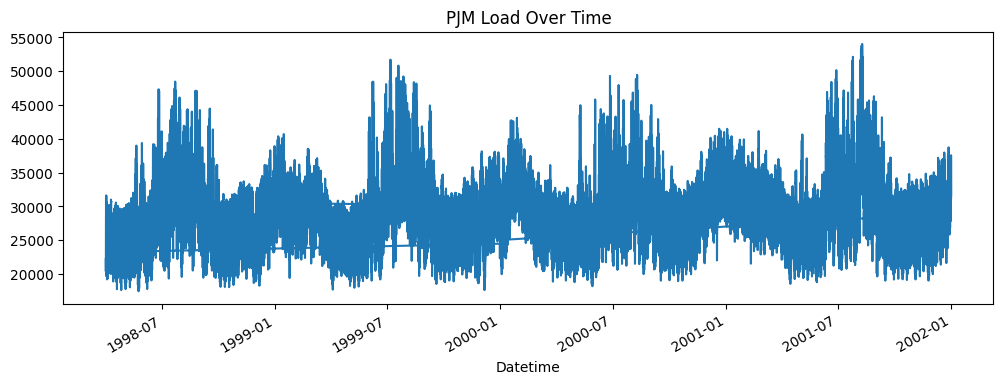

In [ ]:
plt.figure(figsize=(12,4))
df["PJM_Load"].plot(title="PJM Load Over Time")
plt.show()

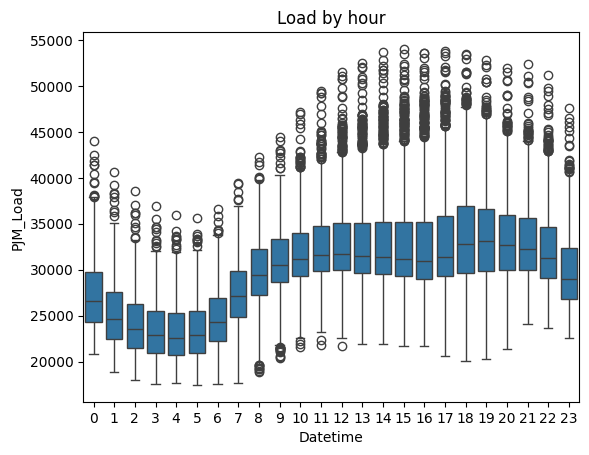

In [ ]:
sns.boxplot(x=df.index.hour, y=df['PJM_Load'])
plt.title("Load by hour")
plt.show()

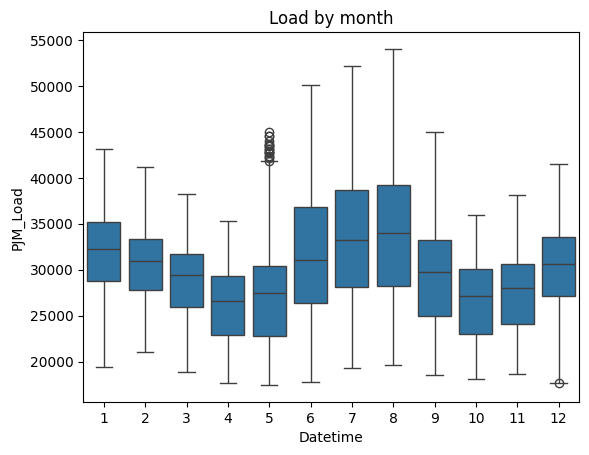

In [ ]:
sns.boxplot(x=df.index.month, y=df['PJM_Load'])
plt.title("Load by month")
plt.show()

In [ ]:
# Drop rows with NaN values after feature engineering and before splitting
df.dropna(inplace=True)

# Adjust split date to be within the available data range after cleaning
train = df[df.index < "2001-01-01"]
test  = df[df.index >= "2001-01-01"]

features = [col for col in df.columns if col != "PJM_Load"]

X_train = train[features]
y_train = train["PJM_Load"]

X_test = test[features]
y_test = test["PJM_Load"]

| learning_rate | Typical n_estimators |
| ------------- | -------------------- |
| 0.3           | 100–300              |
| 0.1           | 300–800              |
| 0.05          | 800–1500             |
| 0.01          | 1500–5000            |


| Value | Behavior    |
| ----- | ----------- |
| 0.3   | aggressive  |
| 0.1   | standard    |
| 0.05  | safer       |
| 0.01  | very stable |


In [ ]:
def objective(trial):
  params = {
      "objective": "reg:squarederror",
      "max_depth": trial.suggest_int("max_depth", 3, 10),
      "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
      "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
      "subsample": trial.suggest_float("subsample", 0.5, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
  }

  model = xgb.XGBRegressor(**params)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)

  mse = mean_squared_error(y_test, preds)

  return np.sqrt(mse)

Why?

Keeps time order

No data leakage

Simulates real forecasting

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:


baseline_xgb_model = xgb.XGBRegressor(
    max_depth = 6,
    learning_rate = 0.1,
    n_estimators = 10000
)

baseline_xgb_model.fit(X_train, y_train)
baseline_predict = baseline_xgb_model.predict(X_test)

mse = mean_squared_error(y_test, baseline_predict)

print(f"Baseline MSE: {mse:.4f}")

Baseline MSE: 361068.9535


Standard:

param_grid = {

    "max_depth": [4,6,8],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [500,1000],
    "subsample": [0.7,0.9],
    "colsample_bytree": [0.7,0.9],
    "gamma": [0, 1],
    "reg_alpha": [0, 0.5],
    "reg_lambda": [1, 2]
}

In [ ]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 12],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_preds = rf_grid.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print(f"Random Forest RMSE: {rf_rmse:.4f}")

Random Forest RMSE: 652.2135


In [ ]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 12],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# param_grid = {
#     "max_depth": [4,6,8],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "n_estimators": [500,1000],
#     "subsample": [0.7,0.9],
#     "colsample_bytree": [0.7,0.9]
# }

param_grid = {
    "max_depth": [4,8],
    "learning_rate": [0.01,0.05,0.1],
    "n_estimators": [500,1000],
    "subsample": [0.6,0.8],
    "colsample_bytree": [0.6,0.8]
}

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [4, 8], 'n_estimators': [500, 1000],
                         'subsample': [0.6, 0.8]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 1000, 'subsample': 0.6}
Best CV RMSE: -737.6347666479808


In [ ]:
from sklearn.metrics import r2_score
best_model = grid.best_estimator_
pred = best_model.predict(X_test)

r2 = r2_score(y_test, pred)
print(f"R-squared (R²): {r2}")

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", grid.best_score_)

R-squared (R²): 0.9888413432897671
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 1000, 'subsample': 0.6}
Best CV RMSE: -737.6347666479808
